[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/QuantumMechanics1/blob/main/QM_py/qm1_wavepack_zad.ipynb)


## Фур'є-розклад хвильових пакетів. Співвідношення невизначеностей Хайзенберга
$\newcommand{\ket}[1]{\left.\left\vert\, #1\,\right. \right \rangle}$
$\newcommand{\bra}[1]{\left. \langle \, #1\, \right\vert}$
$\newcommand{\braket}[2]{\langle \,#1 \vert #2 \, \rangle}$
$\newcommand{\av}[3]{\left\langle \,#1 \left \vert\, #2 \,\right\vert #3 \,\right \rangle}$

Для проведення аналітичних обчислень будемо використовувати Python бібліотеку
<a href="https://docs.sympy.org/0.7.2/tutorial.html#"> SymPy</a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# 
import sympy
from sympy import *
sympy.__version__

'1.14.0'

Фізичні константи містяться у відповідній Python бібліотеці
<a href="https://docs.scipy.org/doc/scipy/reference/constants.html"> SciPy</a>

In [2]:
from scipy import constants
print(type(constants.physical_constants),len(constants.physical_constants))

<class 'dict'> 445


Наприклад

In [3]:
constants.find('Bohr radius')

['Bohr radius']

In [4]:
constants.physical_constants['Bohr radius']

(5.29177210544e-11, 'm', 8.2e-21)

__Задача__ Закон Віна $\omega_{max}\sim T$ дозволив йому сформулювати гіпотезу про те що середня енергія ___однієї___ моди ЕМВ з частотою $\omega$ 

$$U_{\omega} = u_0\,e^{-\frac{u_0}{T}}\,,\quad u_0 \sim \omega$$

що звичайно може розлядатись як твердження про те що енергія моди пропорційна до частоти і відповідним розподілом є розподіл Больцмана. Використвуючи термодинамічну рівність 

$$\left.\frac{dS}{dU}\right\vert_{V} = \frac{1}{T}$$ 

та просту інтерполяційну формулу Планка для ентропії

$$
\frac{d^2 S}{d U^2} =-\frac{a}{U(U+b)}
$$

виведіть формулу Планка для спектральної густини енергії.
<br>
__Рішення__ Нагадаємо, що кількість мод ЕМП в інтервалі частот $d\omega$ у кубічному резонаторі обєма $V = L^3$ дорівнює:
$$dN_{\omega} = 2\,\left(\frac{L}{2\pi}\right)^3\,4\pi\,k^2\,dk = \frac{V}{\pi^2\,c^3}\,\omega^2\,d\omega
$$
тому гіпотеза Віна призводила до спектральної густини енергії
$$
\rho_{\omega} = \frac{1}{V}\frac{d E_{\omega}}{d\omega} = \frac{1}{V}\frac{dN_{\omega}}{d\omega}\,U_{\omega} \sim \frac{\omega^3}{\pi^2\,c^3}\,e^{-\frac{\omega}{T}}
$$
яка добре узгоджувалась із даними для великих частот, але не збігалась із класичним законом Релея-Джинса для малих $\omega: \rho_{\omega}  = \frac{T}{\pi^2\,c^3}\,\omega^2$. Виходячи з гіпотези Віна отримаємо
$$U_{\omega} = u_0\,e^{-\frac{u_0}{T}}\Rightarrow \frac{1}{T} = -\frac{1}{u_0}\,\ln \frac{U_{\omega}}{u_0}$$
При великих значеннях $T$ значення $U$ також будуть великі (максимум Віна зсувається в область великих частот) а отже в інтервалі частот $\omega \ll T/\hbar$, очевидно, повинна діяти класична формула з $U\sim T$, тому між двома граничними випадками
$$ 
\frac{d}{d\,U}\left(\frac{1}{T}\right)\sim \begin{cases}
 -\frac{1}{U^2}\,,& T\gg u_0\,\,\,\, \text{Rayleigh–Jeans} \\
 -\frac{1}{u_0\,U}\,,& T\ll u_0\,\,\,\text{Wien}
\end{cases}
$$ 
зробимо найпростішу інтерполяцію:
$$
\frac{d^2 S}{d U^2} =-\frac{1}{U(U+u_0)}\Rightarrow \frac{1}{T} = \frac{1}{u_0}\,\ln \frac{U+u_0}{U}\Rightarrow U_{\omega} = \frac{u_0}{e^{\frac{u_0}{T}}-1}
$$
Остаточно якщо позначити $u_0 = \hbar\,\omega$ отримаємо:
$$
\rho_{\omega} = \frac{\omega^2}{\pi^2\,c^3} \frac{\hbar\,\omega}{e^{\frac{\hbar\,\omega}{T}}-1}
$$
це і є знаменитий закон Планка.
***

***
__Задача:__ Обчислити зсув довжини хвилі при розсіянні фотона, який розглядається як частинка із певним імпульсом та енергією, на вільному електроні (зсув Комптона).<br>

__Рішення__  Запишемо закони збереження імпульсу та енергії (з урахуванням релятивістського характеру руху електрона)

$$
\label{compton}
\hbar\,\omega_0 + E_0 = \sqrt{(p\,c)^2+E^2_{0}}+\hbar\,\omega \\
\hbar \, \mathbf{k}_0 = \mathbf{p} + \hbar \, \mathbf{k}
$$

$E_0 = m_0\,c^2$ - енергія покою. Проводячи необхідні підстановки:

$$
\hbar^2 (\omega_0 - \omega)^2 + 2\,m_0\,c^2\,\hbar(\omega_0 - \omega) = p^2\,c^2\,,\quad
p^2c^2 = \hbar^2(\omega^2-2\omega\,\omega_0\cos \theta+\omega^2_0)
$$
отримуємо співвідношення частот:
$$
\frac{\hbar}{m_0\,c^2}\,\omega\,\omega_0\,(1-\cos \theta) = (\omega - \omega_0)
$$
в терминах довжини хвилі $\omega = c\frac{2\pi}{\lambda}$ це дає:
$$
\lambda - \lambda_0 = 2\,\Lambda_{C}\,\sin^2\frac{\theta}{2}\,\,.
$$
Характеристична довжина $\Lambda_{C} = \frac{2\pi\,\hbar}{m_0\,c}$ називається комптонівською довжиною хвилі, що для електрона складає $\Lambda_{C}\approx 2.43\cdot 10^{-12}$ м.

In [5]:
from scipy import constants
# Compton length
compl=constants.h/(constants.m_e*constants.c)
print(compl)
print(constants.find('Compton'))
constants.physical_constants[constants.find('Compton')[0]]

2.426310235380317e-12
['Compton wavelength', 'muon Compton wavelength', 'neutron Compton wavelength', 'proton Compton wavelength', 'reduced Compton wavelength', 'reduced muon Compton wavelength', 'reduced neutron Compton wavelength', 'reduced proton Compton wavelength', 'reduced tau Compton wavelength', 'tau Compton wavelength']


(2.42631023538e-12, 'm', 7.6e-22)

Бачимо, що ця довжина відповідає енергії фотона яка дорівнює енергії спокою електрона $E_{0}=m_{0}\,c^2$. Вона менше за розмір атома (боровський радіус) і обмежує точність визначення координати електрона з суто релятивістських квантових еффектів (народження електрон-позитроних пар). Як витікає з формули, комптонівський зсув спостерігається при прямому куті розсіяння $\theta = \pi/2$.

Комптон-ефект симетричний до обернення часу, тобто має місце зворотній ефект - збільшення енергії фотона при зіткненні з високоенергетичним електроном ([ефект Сюняєва-Зєльдовича](https://en.wikipedia.org/wiki/Sunyaev–Zeldovich_effect)). Зокрема він спричиняє відхилення густини фонового теплового випромінювання Всесвіту від планківської завдяки наявності гарячого електронного газа у скупченнях галактик (galaxy clusters) за яким такі скупчення і виявляють. 

In [6]:
#u,u0,t=symbols('u,u0,t',real=True)
#solve(integrate(-1/(u*(u+u0)),u)-1/t,u)

<a id='zad_rect'></a>
__Задача:__ Стан системи задано фінітним пакетом<a id='wvpack_rect'></a>:
\begin{equation}\label{eq:packrect}
\psi(x) = \left\{\begin{array}{cc}
  C\,, & |x|\le a/2 \\
&\\
  0\,, & |x| > a/2
\end{array} = \theta(x+a/2)\theta(a/2-x) \right.
\end{equation}
де $\theta$ - функція Хевісайда . Визначте амплітуди хвиль де Бройля, які формують цей пакет. Переконайтесь у віконанні  співвідношеня невизначеності. Побудуйте стан у граничному випадку $a \to 0$.<br>

__Рішення__ По перше знайдемо константу нормування:
$$
C = \frac{1}{\sqrt{a}}
$$
і дисперсію координати
$$
\sqrt{\langle \Delta x^2 \rangle} = \frac{a}{2\,\sqrt{3}} 
$$
Амплітуди хвиль де Бройля  як функції хвильового вектора знаходяться елементарним інтегруванням:
$$
c(k) = \frac{1}{\sqrt{2\pi\,a}}\,\int\limits_{-a/2}^{a/2}\,e^{-i\,k\,x}\,dx = 
\sqrt{\frac{2}{\pi\,a}}\,\frac{\sin{\frac{k\,a}{2}}}{k}
$$
або в імпульсному представленні:
$$
\tilde{c}(p) = \frac{1}{\sqrt{\hbar}}\,c\left(\frac{p}{\hbar}\right) = 
\sqrt{\frac{2\,\hbar}{\pi\,a}}\,
\frac{\sin\left(\frac{p\,a}{2\hbar}\right)}{p}
$$

In [7]:
x, k = symbols('x k',real=True)
a=symbols('a',positive=True)
#simplify(1/a*integrate(x**2,[x,-a/2,a/2]))#x-disp
simplify(1/sqrt(2*pi*a)*integrate(exp(-I*k*x),[x,-a/2,a/2]))

Piecewise((sqrt(2)*sin(a*k/2)/(sqrt(pi)*sqrt(a)*k), (k > 0) | (k < 0)), (sqrt(2)*sqrt(a)/(2*sqrt(pi)), True))

In [8]:
# 
from ipywidgets import interactive
import ipywidgets as widgets

In [9]:
# from IPython.display import display
# w = widgets.IntSlider()
# display(w)
#
def f(w):
    plt.figure(figsize=(9, 3))
    plt.subplot(121)
#     plt.figure()
    x = np.linspace(-3, 3, num=100)
    plt.plot(x, np.heaviside(w/2-x,1)*np.heaviside(x+w/2,1)/np.sqrt(w))
    plt.fill_between(x,np.heaviside(w/2-x,1)*np.heaviside(x+w/2,1)/np.sqrt(w),y2=0,color='xkcd:sky blue')
    plt.title("x-rectangular packet")
    # 
    plt.subplot(122)
    k = np.linspace(-25,25, num=100)
    plt.plot(k, np.sqrt(2/(np.pi*w))*np.sin(k*w/2)/k)
    plt.fill_between(k, np.sqrt(2/(np.pi*w))*np.sin(k*w/2)/k,y2=0,color='xkcd:sky blue')
    plt.title("its k-fourier transform")
    plt.show()
#
interactive(f, w=(0.1, 4, 0.1))

interactive(children=(FloatSlider(value=2.0, description='w', max=4.0, min=0.1), Output()), _dom_classes=('wid…

Таким чином, у формуванні фінітного прострового пакета
задіян практично увесь набір плоских хвиль, за виключенням
хвиль із $k_{n} = n\,\pi/a\,,\,n\in \mathbb{Z}$.

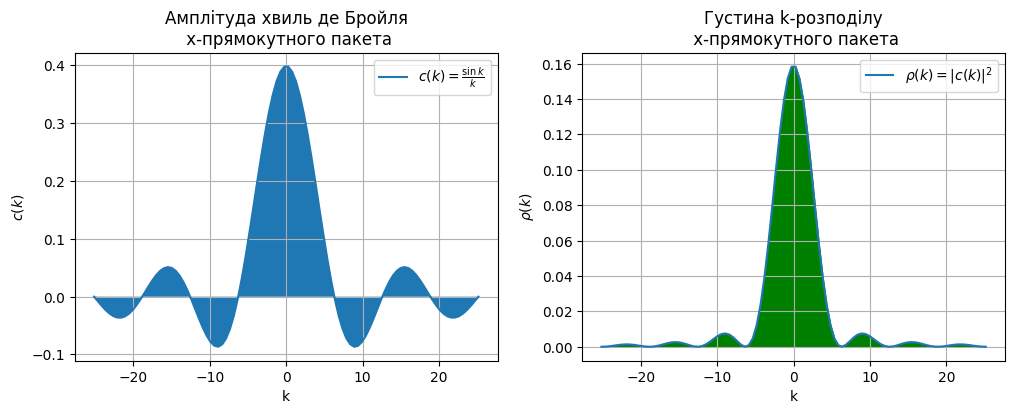

In [10]:
#
k=np.linspace(-8*np.pi,8*np.pi,100)
ck=np.sin(k/2)/k*np.sqrt(2/np.pi)
#
plt.figure(figsize=(12, 4))
#
plt.subplot(121)
p1=plt.plot(k,ck,label=r'$c(k)=\frac{\sin{k}}{k}$') #note "r" character if you want to use LaTeX
plt.xlabel('k')
plt.ylabel('$c(k)$')
plt.fill_between(k,ck,y2=0) #filled region between plot and x-axis
plt.title("Амплітуда хвиль де Бройля\n x-прямокутного пакета")
plt.grid(True)
plt.legend()
#
plt.subplot(122)
p2=plt.plot(k,ck**2,label=r'$\rho(k)=|c(k)|^2$') #note "r" character if you want to use LaTeX
plt.xlabel('k')
plt.ylabel(r'$\rho(k)$')
plt.fill_between(k,ck**2,y2=0,color='g')
plt.title("Густина k-розподілу\n x-прямокутного пакета")
plt.grid(True)
plt.legend()
plt.show()

Відповідно до [рівності Планшереля](https://colab.research.google.com/github/kulinskij-tech/QuantumMechanics1/blob/main/QM_py/qm1_wavepack_theor.ipynb), ми отримуємо інтеграл:
$$\int\limits_{-\infty}^{+\infty}
\frac{\sin^2{k}}{k^2}\,dk = \pi\,.
$$

In [11]:
integrate(sin(x)**2/x**2,[x,-oo,+oo])

pi

Зрозуміло, що для такого стана середнє значення, дисперсія та інші моменти імпульсу невизначено (відповідні інтеграли розбігаються)

In [12]:
integrate(sin(x)**2/x,[x,-oo,+oo])

nan

Розглянемо як відтворюється функція при зворотньому перетворенні, якщо поступово включати все більший інтервал хвильових векторів $k_0$.
<!-- <a id='fig_rectk0'></a> -->

$$
\psi(x,k_0) = \int\limits_{-k_0}^{k_0}\,c(k)\,e^{i\,k\,x}\,d\,k
$$

In [13]:
x=Symbol('x',real=True)
k=Symbol('k',real=True)
k0=Symbol('k0',real=True)
a=Symbol('a',positive=True)
si=sqrt(2)/(S.Pi)*integrate(sin(a*k)*cos(k*x)/k,[k,0,k0])
si

sqrt(2)*(Si(k0*(a - x))/2 + Si(k0*(a + x))/2)/pi

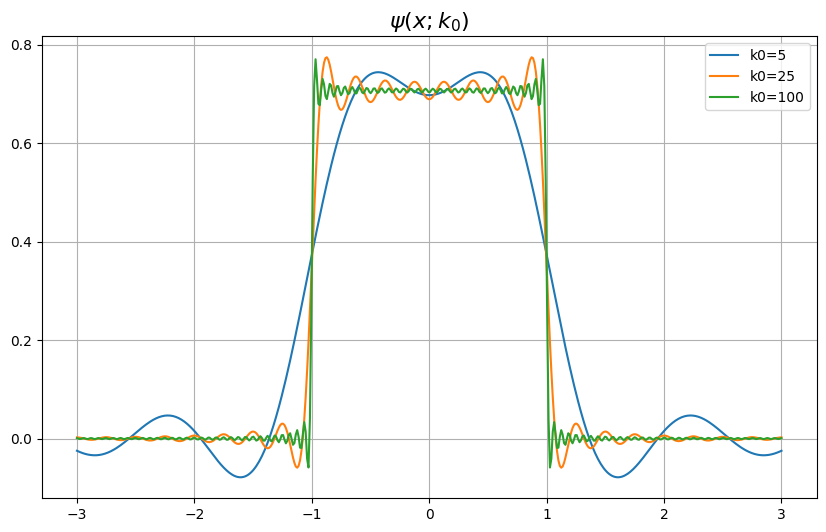

In [14]:
from scipy import special
#
xsi=np.linspace(-3,3,500)
#
plt.figure(figsize=(10, 6))
def ysi(x,k0):
    s=(special.sici(k0*(1+x))[0]+special.sici(k0*(1-x))[0])/(np.sqrt(2)*np.pi)
    return plt.plot(xsi,s,label='k0='+str(k0))
#

for k0 in [5,25,100]:
    ysi(xsi,k0)
#
plt.legend()
plt.title('$\\psi(x;k_0)$',size=16)
plt.grid(True)
plt.show()

In [15]:
# from sympy.plotting import PlotGrid
# s0=True
# p0=plot(si.subs(k0,5).subs(a,1),(x,-3,3),ylim=(-0.1,1),
#         title=r'$\psi(x)$: Inverse Fourier image at $k_0$=5',ylabel=False,show=s0)
# p1=plot(si.subs(k0,10).subs(a,1),(x,-3,3),ylim=(-0.1,1),
#         title=r'$\psi(x)$: Inverse Fourier image at $k_0$=10',ylabel=False,show=s0)
# p2=plot(si.subs(k0,50).subs(a,1),(x,-3,3),ylim=(-0.1,1),
#         title=r'$\psi(x)$: Inverse Fourier image at $k_0$=50',ylabel=False,show=s0)
# p3=plot(si.subs(k0,100).subs(a,1),(x,-3,3),ylim=(-0.1,1),
#         title=r'$\psi(x)$: Inverse Fourier image at $k_0$=100',ylabel=False,show=s0)
# PlotGrid(2,2,p0,p1,p2,p3)


Як видно, функція "майже" відтворюється за виключенням точок порушення неперервності (стрибкі 1-го роду). Це природньо, оскільки в загальномк випадку перетворення Фур'є збігається до функції не поточково, а тільки у сенсі норми (відстані) простору $L_2$ тобто у середньоквадратичному:
$$
\left|\left|\lim\limits_{K\to \infty}\,\frac{1}{\sqrt{2\pi}}\,\int\limits_{-K}^{K} c(k)\,e^{i\,k\,x}\,dk - \psi(x)
\right|\right|_{L_2}\to 0
$$
Тільки якщо функція гладка і зникає (разом зі всіма своїми похідними) на нескінченності швижше за довільну степень свого аргументу, тоді її Фур'є зображення є функцією такого же класу (приклад: гаусівський пакет).

У точках розриву [див Рис](#fig_rectk0) можна побачити т.з. [явище Гіббса](https://en.wikipedia.org/wiki/Gibbs_phenomenon) - стабілізація надлишкової амплітуди осциляцій поблизу точок розриву 1-го роду. Величина такого стрибка є універсальною, оскільки у околі розриву 1-го роду функцію можна наблизити стандартною функцією-сходинкою (функція Хевісайда).
Співвідношення Хайзенберга виконується, оскільки дисперсія хвильового числа $k$ необмежена.<br>

Розглянемо випадок $a\to 0$. З отриманих вище результатів доходимо висновку що 
$$\forall k\,\,  c(k)\to 0 \Rightarrow \psi \to 0$$
Для того щоб отримати нетривіальний стан із $c(k)\ne 0$ потрібно змінити константу нормування на $C = a$ так що тепер:
$$
c(k;a) = \sqrt{\frac{2}{\pi}}\,\frac{\sin{k\,a}}{k\,a}\,\, \Rightarrow\,\, \lim\limits_{a\to 0} c(k;a) = \frac{1}{\sqrt{2\pi}}
$$
тобто ми отримали відоме <a id='deltaintsincpi'>Фур'є-зображення $\delta$-функції:</a>
$$
\frac{1}{2\pi}\int_{-\infty}^{+\infty} \,e^{i\,k\,x}\,dx = \delta(x)
$$
для якої всі Фур'є-амплітуди є однаковими. Такий стан $\psi(x) = \delta(x)$ не може бути нормований у сенсі $L_2$-норми але він може розглядатися як граничний випадок стану локалізації частинки "у точці". Введення $\delta$-функцій дозволяє оперувати із такими станами формально як і зі звичайними фізичними станами $\psi \in L_2$. Наприклад інтеграл
$$
\int\limits_{-\infty}^{+\infty}
\frac{\sin{x}}{x}\,dx  = \pi
$$

In [16]:
integrate(sin(a*x)/x,[x,-oo,+oo])

pi

може бути обчислений "за допомогою квантової механіки із $\delta$-функцією" завдяки незалежності скалярного добутку функцій від конкретного представлення ($x$ чи $k$). Дійсно:

$$
\frac{1}{\pi}\,\int\limits_{-\infty}^{+\infty} 1\,\frac{\sin{k}}{k}\,dk = \int\limits_{-1}^{+1} \delta(x)\,dx = 1
$$

у подальшому ми покажемо як це можна інтерпретувати з фізичної точки зору та геометрії простору станів квантовомеханічної системи.<br>

Функція $\frac{\sin x}{x}$, яка є фур'є-зображенням прямокутного сигналу доволі часто зустрічається у задачах пов'язаних із дифракційними ефектами і в неї навіть є власне ім'я - ${\rm sinc}$.
Для довільої функції $\psi(x)\in L_{2}$ та її Фур'є-зображення $c(k)\in L_{2}$ виконується співвідношення:
***
\begin{equation}\label{eq:sincpsi}
\sqrt{\frac{2}{\pi}}\,\int\limits_{-\infty}^{+\infty}{\rm sinc}(k)\,c(k)\,dk = \int\limits_{-1}^{1}\,\psi(x)\,dx\,.
\end{equation}
***
На формулі \eqref{eq:sincpsi} заснована <a href='https://habr.com/ru/post/146140/'>гумористична історія</a> з приводу послідовності значень інтегралів:
$$
\Pi_{n}=\int\limits_{-\infty}^{+\infty}\prod\limits_{q=1}^{n}\,{\rm sinс}\left(\frac{k}{2q-1}\right)\\
\begin{cases}
\Pi_{n} =& \frac{\pi}{2}\,,\quad \text{if}\, n<8\\
\Pi_{n} <& \frac{\pi}{2}\,,\quad \text{if}\, n\ge 8
\end{cases}
$$

In [ ]:
n0, a, inta = symbols('n0 a inta',integer=True)
n0=3;a=1;
for i in range(n0):
    a=a*sin(x/(2*i+1))/(x/(2*i+1))
    print('integral on '+ str(a)+' equals')
    inta=integrate(a,[x,0,+oo])
    print(inta)

integral on sin(x)/x equals
pi/2
integral on 3*sin(x/3)*sin(x)/x**2 equals
pi/2
integral on 15*sin(x/5)*sin(x/3)*sin(x)/x**3 equals


<a href='https://mathoverflow.net/questions/11517/computer-algebra-errors/11607#11607'>оригінал тут</a>. Оскільки WolframMath працює із цим прикладом швидше ніж SymPy
[тут реалізація коду з використанням WL](https://colab.research.google.com/github/kulinskij-tech/QuantumMechanics1/blob/main/QM_py/sinc_wolfram.ipynb)<br>
Увага! потрібно встановити <a href="https://www.wolfram.com/developer/"> Free Wolfram Engine for Developers</a> та
<a href="https://github.com/WolframResearch/WolframLanguageForJupyter">зв'язати його із Jupyter</a>.

<a id='zad_heiswvpack'></a>
__Задача__ Покажемо, що співвідношення Хайзенберга для дисперсій координати і імпульса спираючись на властивість перетворення Фур'є швидкозникаючої функції. Фур'є-образи такої функції та її похідної пов'язані рівністю:
$$
F[\psi^{(n)}] = (i\,k)^{n}\,F[\psi]
$$
__Рішення__ Розглянемо функцію:
$$
f_{\lambda}(x)=\left(\,\lambda\,\frac{d}{d\,x} + x\right)
\psi(x)\,,\quad \lambda \in \mathbb{R}.
$$
Зсувом початку відліку можна вважати що:
$$\left\langle\, x \,\right\rangle = 0\,,\quad \left\langle\, k
\,\right\rangle = 0\,.
$$
Припустимо, що $f_{\lambda}(x)\in L_2$.
Тоді,
$$
0 < \int\,|f_{\lambda}(x)|^2\,dx = \int\,|f_{\lambda}(x)|^2\,dx
=\int\,\left(\,\lambda\, \frac{d}{d\,x} + x\right)
\psi^*(x)\,\left(\lambda\,\frac{d}{d\,x} + x\right) \psi(x)\,dx
$$
$$
\lambda^2 \int\,\left|\frac{d\psi}{d\,x}\right|^2\,dx +\int
\,x^2\,|\psi|^2\,dx + \lambda\,\int\left(x\,\psi^*
\frac{d\psi}{d\,x} + x\,\psi\,\frac{d\psi^*}{d\,x}\right)\,dx =
$$
$$
\lambda^2 \Delta k^2 +\Delta x^2 + \lambda\,\int\left(
\frac{d}{d\,x}\left( x\,|\psi|^2\,\right)-|\psi|^2\right)\,dx =
\lambda^2 \Delta k^2 - \lambda +\Delta x^2 \ge 0
$$

Условие неотрицательности квадратного трехчлена имеет вид:
$$
  1 - 4\Delta k^2 \,\Delta x^2 \le 0 \Rightarrow \Delta k \,\Delta
  x \ge 1/2\,.
$$
Q.E.D.

__Задача__ Перевіремо виконання співвідношення невизнченностей для гаусівського пакету
$$
\psi(x) = C\,\exp\left(-\frac{x^2}{2\,a^2}\right)
$$
__Рішення__ Спочтку нагадаємо обчислення інтеграла Пуассона:
\begin{align*}
	I = \int\limits_{-\infty}^{+\infty}\exp{\left(-\frac{x^2}{2\,a^2}\right)}\,dx = a
	\sqrt{\int\limits_{-\infty}^{+\infty}\exp{\left(-\frac{x^2}{2}\right)}\,dx\,
		\int\limits_{-\infty}^{+\infty}\exp{\left(-\frac{y^2}{2}\right)}\,dy} =&
	\\
	\sqrt{2\,\pi\int\limits_{0}^{+\infty}
		\exp{\left(-\frac{\rho^2}{2}\right)}\,\rho\,d\rho}\,=
	a\,\sqrt{2\,\pi}&\,,
	\end{align*}
звідки отримуємо:
$$
C\,=\, \left(\int\limits_{-\infty}^{+\infty}\exp(-x^2/a^2)\,dx\right)^{-1/2} =\frac{1}{\sqrt{a\,\sqrt{\pi}}}\,.
$$ 
Знайдемо фур'є-амплітуди $c(k)$:
\begin{align*}
	c(k) = \frac{1}{\sqrt{2\,\pi}}
	\int\limits_{-\infty}^{+\infty} \psi(x,0)\exp(-i\,k\,x)\, d\,x\,
	=&\,\frac{C}{\sqrt{2\,\pi}}
	\int\limits_{-\infty}^{+\infty}
	\exp\left(-\frac{x^2}{2\,a^2}-i\,k\,x\right)\, d\,x\,
	=\,&\notag\\
	\frac{C\,a}{\sqrt{2\,\pi}} \int\limits_{-\infty}^{+\infty}
	\exp\left(-\frac{u^2}{2}-i\,k\,a\,u\right)\, d\,u =&
	\notag \\
	\frac{C\,a}{\sqrt{2\,\pi}} \int\limits_{-\infty}^{+\infty} \exp\left(-\frac{(u +
		i\,k\,a)^2}{2}-\frac{k^2\,a^2}{2}\right)&\, d\,u\, =\,
	C\,a\exp\left(-\frac{k^2\,a^2}{2}\right)
\end{align*}
Тобто гаусівський пакет має однакову форму і в координатному і в імпульсному просторі. 
Тепер можна знайти дисперсію хвильового вектора:
$$
\Delta k = a\,C\sqrt{\int\limits_{-\infty}^{+\infty} k^2 \exp\left(-a^2\,k^2\right)\,dk}= 
\frac{1}{a\,\sqrt{2}}
$$
Результат:
$$
\Delta x\, \Delta k = \frac{1}{2}
$$
тобто у такому стані досягається нижня границя співвідношення Хайзенберга.

Символічне обчислення x-дисперсії

In [ ]:
a=symbols('a',positive=True)
gauss=symbols('gauss')
gauss=exp(-x**2/(2*a**2))
cnorm=1/sqrt(2*integrate(gauss**2,[x,0,+oo]))
dx=cnorm*sqrt(2*integrate((x*gauss)**2,[x,0,+oo]))
dx

Символічне обчислення k-дисперсії

In [ ]:
gf=simplify(integrate(gauss*exp(-I*k*x)*cnorm/sqrt(2*pi),[x,-oo,+oo]))
dk=sqrt(2*integrate(gf**2*k**2,[k,0,+oo]))
dk

Результат:

In [ ]:
dx*dk

__Задача:__ Використовуючи співвідношення невизначенності для імпульса та координати,
знайти найменше значення функції 
$$H(p,x) =\frac{p^{\,2}}{2\,m} + \frac{m\,\omega^{\,2}\,x^{\,2}}{2}$$
яка представляє енергію лінійного осцилятора.<br>
__Рішення__ Стан із найменшою енергією є таким що
$$
\langle x \rangle = 0 = \langle p \rangle 
$$
Тому з рівностей:
$$
\langle H \rangle = \frac{\langle \Delta p^2 \rangle}{2\,m}+ m\,\omega^2\,\frac{\langle \Delta x^2 \rangle}{2} 
$$
і
$$
\Delta x \Delta p \ge \frac{\hbar}{2} 
$$
отримуємо відповідь:
$$
\min{\langle H \rangle}  = \frac{1}{2}\, \hbar\,\omega
$$
<a id='enrgosc0'>це є т.з. енергія "нульових" квантових коливань осцилятора яка на віміну від класичного випадку не дорівнює 0</a>. <br>
З попередньої задачі виходить, що хвильова функція такого стану у х-представленні має вигляд
$$
\psi_{0}(x) = \exp\left(-\frac{x^2}{4\,\langle\Delta x^2\rangle}\right)\,,\\ 
\Delta x =  \sqrt{\frac{\hbar}{2\,m\,\omega}}\,,\,\,\, \Delta p =  \sqrt{\frac{\hbar \,m\,\omega}{2}}
$$
***

### Задачі для самостійної роботи:
__Задача:__ Все теж саме що і в [Задачі](#zad_rect)  відтворити для прямокутного імпульсного пакета:
$$
c(k;k_0) = \left\{\begin{array}{cc}
  C\,, & |k-k_0|\le \frac{\delta k}{2} \\
&\\
  0\,, & |k-k_0| > \frac{\delta k}{2}
\end{array}\, \right.
$$
зокрема знайти хвильову функцію $\psi(x)$ у координатному просторі, побудувати густину ймовірності, знайти середнє та дисперсію координати та імпульсу. Побудувати нетривіальний стан у границі $\delta k \to 0$.
***
__Задача__ Використовуючи [попередні результати](#deltaintsincpi), довести, що
$$
\forall a > 0\,:\,\, \int_{-\infty}^{+\infty} \frac{\sin{a\,k}}{k}\,dk = \pi
$$
та обчислити інтеграл ($a_1,a_2>0$)
$$
\int_{-\infty}^{+\infty} \frac{\sin{k\,a_{1}}\,\sin{k\,a_{2}}}{k^2}\,dk
$$
***
__Задача__ Запишіть відповідне співвідношення для Фур'є-амплітуд прямоугольних пакетів у загальному випадку їх розташування.
***
__Задача__ Знайдіть x-представлення хвильового пакету Фурє-амплітуди якого мають вигляд
$$
c(k) = C\, {\rm sinc}^2(k)
$$
Перевірити співвідношення Хайзенберга.
***
__Задача:__ Знайти розклад за плоскими хвилями для станів:
$$
\psi(x) = C\,e^{-|x|/a}\,,\quad a>0\,, \quad \psi(x) = \frac{C}{\sqrt{x^2_0+x^2}}\,,\quad \psi(x) = C\,\exp\left(-\frac{x^2}{2\,a^2}\right)
$$
Перевірити співвідношення Хайзенберга. (Візуалізацію залежності характеру локалізації пакетів в $x$ та $k$ просторах можна зробити за допомогою <a href=https://ipywidgets.readthedocs.io/en/latest/> widgets</a>)
***
__Задача__ Поясніть зв'язок між хвильовими пакетами з функціями $\psi(x)$ та $\psi(x)\, e^{i\,k_0\,x}$. Дайте фізичну інтерпретацію результату.

***
__Задача__ Використовуючи дані графіка (бажано оцифрувати графік знявши дані з растрової картинки) супутника 
<a href=http://lambda.gsfc.nasa.gov/product/cobe/firas_image.cfm>COBE (1992)</a>, встановіть за формулою Планка температуру реліктового випромінювання.
***
<img src="./figs/fig_plankcobe.png" alt="Image" width="400" height="100">

***
[Перехід до задач про часову еволюцію](https://colab.research.google.com/github/kulinskij-tech/QuantumMechanics1/blob/main/QM_py/qm1_wavepack_zadevolut.ipynb)